# endpoint w FastAPI

chat GPT:  https://chatgpt.com/g/g-p-6a225d72bfd0819195fb28948eae59fc/c/6a2149df-d2f0-8393-bbfa-209ab56eea12

## Krok_1. Zatrzymaj FastAPI

W terminalu z uvicorn:

CTRL + C

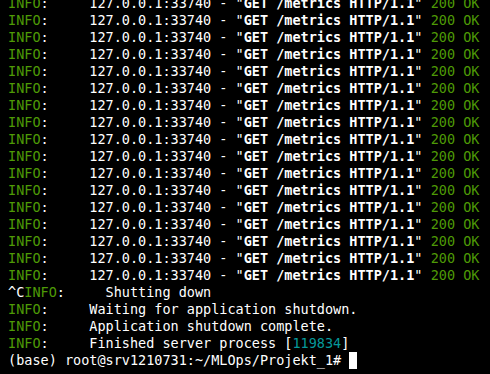

## Krok_2. Otwórz plik

    nano app/main.py

In [24]:
import os
import json
import sqlite3
import uuid
import time
from datetime import datetime, timezone

import mlflow
import mlflow.pyfunc
import pandas as pd

from fastapi import FastAPI, Response
from pydantic import BaseModel

from prometheus_client import (
    Counter,
    Histogram,
    Gauge,
    generate_latest,
    CONTENT_TYPE_LATEST
)


# ============================================================
# CONFIG
# ============================================================

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
MODEL_URI = "models:/warsaw_flat_price_model@champion"
PREDICTION_DB = "prediction_logs.db"
DRIFT_REPORT_PATH = "outputs/drift_report.json"


# ============================================================
# PROMETHEUS METRICS
# ============================================================

PREDICTIONS_TOTAL = Counter(
    "flat_price_predictions_total",
    "Total number of flat price predictions"
)

PREDICTION_ERRORS_TOTAL = Counter(
    "flat_price_prediction_errors_total",
    "Total number of prediction errors"
)

PREDICTION_LATENCY_SECONDS = Histogram(
    "flat_price_prediction_latency_seconds",
    "Prediction latency in seconds"
)

LAST_PREDICTED_PRICE_PLN = Gauge(
    "flat_price_last_predicted_price_pln",
    "Last predicted flat price in PLN"
)

LAST_AREA_M2 = Gauge(
    "flat_price_last_area_m2",
    "Last input flat area in square meters"
)

LAST_DISTANCE_FROM_CENTER_KM = Gauge(
    "flat_price_last_distance_from_center_km",
    "Last input distance from Warsaw center in kilometers"
)

LAST_RENT_PLN = Gauge(
    "flat_price_last_rent_pln",
    "Last input rent in PLN"
)

DATA_DRIFT_DETECTED = Gauge(
    "flat_price_data_drift_detected",
    "Data drift detected flag: 1 = drift detected, 0 = no drift"
)

DRIFT_PRODUCTION_ROWS = Gauge(
    "flat_price_drift_production_rows",
    "Number of production rows used in drift report"
)


# ============================================================
# DATABASE INIT
# ============================================================

def init_prediction_db():
    conn = sqlite3.connect(PREDICTION_DB)
    cursor = conn.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS prediction_logs (
            request_id TEXT PRIMARY KEY,
            timestamp TEXT,
            distance_from_center_km REAL,
            area_m2 REAL,
            floor INTEGER,
            district TEXT,
            rent_pln REAL,
            predicted_price_pln REAL,
            model_uri TEXT
        )
    """)

    conn.commit()
    conn.close()


def save_prediction_log(
    request_id,
    distance_from_center_km,
    area_m2,
    floor,
    district,
    rent_pln,
    predicted_price_pln,
    model_uri
):
    conn = sqlite3.connect(PREDICTION_DB)
    cursor = conn.cursor()

    cursor.execute("""
        INSERT INTO prediction_logs (
            request_id,
            timestamp,
            distance_from_center_km,
            area_m2,
            floor,
            district,
            rent_pln,
            predicted_price_pln,
            model_uri
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        request_id,
        datetime.now(timezone.utc).isoformat(),
        distance_from_center_km,
        area_m2,
        floor,
        district,
        rent_pln,
        predicted_price_pln,
        model_uri
    ))

    conn.commit()
    conn.close()


# ============================================================
# DRIFT HELPERS
# ============================================================

def load_drift_report():
    if not os.path.exists(DRIFT_REPORT_PATH):
        return {
            "status": "missing",
            "message": "Drift report not found. Run: python src/monitoring/drift_report.py"
        }

    with open(DRIFT_REPORT_PATH, "r") as f:
        return json.load(f)


def update_drift_prometheus_metrics():
    report = load_drift_report()

    if report.get("status") != "ok":
        DATA_DRIFT_DETECTED.set(0)
        DRIFT_PRODUCTION_ROWS.set(0)
        return report

    drift_flag = 1 if report.get("drift_detected") else 0
    production_rows = report.get("production_rows", 0)

    DATA_DRIFT_DETECTED.set(drift_flag)
    DRIFT_PRODUCTION_ROWS.set(production_rows)

    return report


# ============================================================
# LOAD MODEL FROM MLFLOW
# ============================================================

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
model = mlflow.pyfunc.load_model(MODEL_URI)


# ============================================================
# FASTAPI APP
# ============================================================

app = FastAPI(
    title="Warsaw Flat Price Prediction API",
    description="Simple ML API for predicting flat prices in Warsaw",
    version="1.0.0"
)

init_prediction_db()


# ============================================================
# INPUT SCHEMA
# ============================================================

class FlatInput(BaseModel):
    distance_from_center_km: float
    area_m2: float
    floor: int
    district: str
    rent_pln: float


# ============================================================
# BASIC ENDPOINTS
# ============================================================

@app.get("/")
def root():
    return {
        "message": "Warsaw Flat Price Prediction API is running"
    }


@app.get("/health")
def health():
    return {
        "status": "ok",
        "model_uri": MODEL_URI
    }


# ============================================================
# PREDICTION ENDPOINT
# ============================================================

@app.post("/predict")
def predict(flat: FlatInput):

    start_time = time.time()

    try:
        input_df = pd.DataFrame([{
            "distance_from_center_km": flat.distance_from_center_km,
            "area_m2": flat.area_m2,
            "floor": flat.floor,
            "district": flat.district,
            "rent_pln": flat.rent_pln
        }])

        prediction = model.predict(input_df)
        predicted_price = round(float(prediction[0]), 2)

        request_id = str(uuid.uuid4())

        save_prediction_log(
            request_id=request_id,
            distance_from_center_km=flat.distance_from_center_km,
            area_m2=flat.area_m2,
            floor=flat.floor,
            district=flat.district,
            rent_pln=flat.rent_pln,
            predicted_price_pln=predicted_price,
            model_uri=MODEL_URI
        )

        PREDICTIONS_TOTAL.inc()
        LAST_PREDICTED_PRICE_PLN.set(predicted_price)
        LAST_AREA_M2.set(flat.area_m2)
        LAST_DISTANCE_FROM_CENTER_KM.set(flat.distance_from_center_km)
        LAST_RENT_PLN.set(flat.rent_pln)

        return {
            "request_id": request_id,
            "predicted_price_pln": predicted_price,
            "model_uri": MODEL_URI
        }

    except Exception:
        PREDICTION_ERRORS_TOTAL.inc()
        raise

    finally:
        latency = time.time() - start_time
        PREDICTION_LATENCY_SECONDS.observe(latency)


# ============================================================
# RECENT LOGS ENDPOINT
# ============================================================

@app.get("/logs/recent")
def recent_logs(limit: int = 10):
    conn = sqlite3.connect(PREDICTION_DB)

    logs = pd.read_sql_query(
        """
        SELECT *
        FROM prediction_logs
        ORDER BY timestamp DESC
        LIMIT ?
        """,
        conn,
        params=(limit,)
    )

    conn.close()

    return logs.to_dict(orient="records")


# ============================================================
# MONITORING SUMMARY ENDPOINT
# ============================================================

@app.get("/monitoring/summary")
def monitoring_summary():
    conn = sqlite3.connect(PREDICTION_DB)

    logs = pd.read_sql_query("""
        SELECT *
        FROM prediction_logs
    """, conn)

    conn.close()

    if logs.empty:
        return {
            "message": "No prediction logs yet"
        }

    total_predictions = len(logs)

    avg_predicted_price = logs["predicted_price_pln"].mean()
    avg_area_m2 = logs["area_m2"].mean()
    avg_distance = logs["distance_from_center_km"].mean()
    avg_rent = logs["rent_pln"].mean()

    min_predicted_price = logs["predicted_price_pln"].min()
    max_predicted_price = logs["predicted_price_pln"].max()

    most_common_districts = (
        logs["district"]
        .value_counts()
        .head(5)
        .to_dict()
    )

    return {
        "total_predictions": int(total_predictions),
        "avg_predicted_price_pln": round(float(avg_predicted_price), 2),
        "min_predicted_price_pln": round(float(min_predicted_price), 2),
        "max_predicted_price_pln": round(float(max_predicted_price), 2),
        "avg_area_m2": round(float(avg_area_m2), 2),
        "avg_distance_from_center_km": round(float(avg_distance), 2),
        "avg_rent_pln": round(float(avg_rent), 2),
        "most_common_districts": most_common_districts,
        "model_uri": MODEL_URI
    }


# ============================================================
# DRIFT MONITORING ENDPOINT
# ============================================================

@app.get("/monitoring/drift")
def monitoring_drift():
    report = update_drift_prometheus_metrics()
    return report


# ============================================================
# PROMETHEUS METRICS ENDPOINT
# ============================================================

@app.get("/metrics")
def prometheus_metrics():
    update_drift_prometheus_metrics()

    return Response(
        content=generate_latest(),
        media_type=CONTENT_TYPE_LATEST
    )

## Krok 3. Najpierw odśwież raport dryftu

    python src/monitoring/drift_report.py

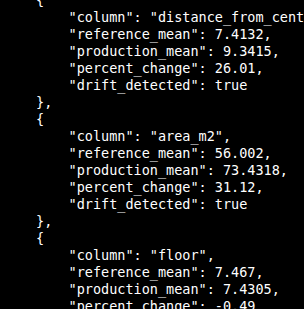

## Krok 4. Uruchom FastAPI

    uvicorn app.main:app --host 127.0.0.1 --port 8000


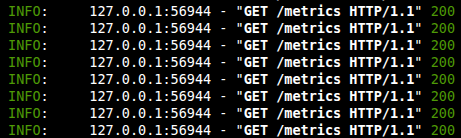

## Krok 5. W drugim terminalu sprawdź endpoint dryftu

    curl http://127.0.0.1:8000/monitoring/drift

Powinieneś zobaczyć raport JSON.

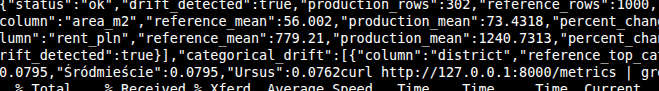

## Krok 6. Sprawdź metryki dryftu dla Prometheusa

    curl http://127.0.0.1:8000/metrics | grep drift

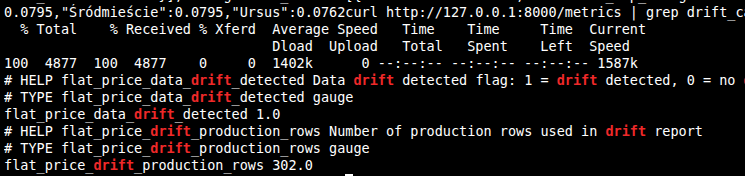

Szukaj tego:

 - flat_price_data_drift_detected 1.0
 - flat_price_drift_production_rows 302.0

Jeżeli flat_price_data_drift_detected ma wartość 1, to znaczy: dryft wykryty

Jeżeli ma wartość 0, to znaczy: dryft niewykryty

Następny krok: dodamy ten sygnał dryftu do Grafany jako osobny panel.

# Teraz dodajemy do Grafany panel:

    DRIFT DETECTED
    0 = brak dryftu
    1 = dryft wykryty

# Krok 1. Najpierw odśwież raport dryftu

Na VPS:

    python src/monitoring/drift_report.py

Potem sprawdź, czy FastAPI wystawia metrykę dryftu:

    curl http://127.0.0.1:8000/metrics | grep drift
    

## Krok 2. Otwórz dashboard JSON

    nano monitoring/grafana/flat_price_dashboard.json

In [ ]:
{
  "dashboard": {
    "id": null,
    "uid": "flat-price-mlops-dashboard",
    "title": "Flat Price MLOps Dashboard",
    "tags": ["mlops", "fastapi", "mlflow", "prometheus", "drift"],
    "timezone": "browser",
    "schemaVersion": 39,
    "version": 2,
    "refresh": "5s",
    "panels": [
      {
        "type": "stat",
        "title": "Total predictions",
        "gridPos": {"x": 0, "y": 0, "w": 6, "h": 4},
        "targets": [
          {
            "expr": "flat_price_predictions_total",
            "refId": "A"
          }
        ]
      },
      {
        "type": "stat",
        "title": "Prediction errors",
        "gridPos": {"x": 6, "y": 0, "w": 6, "h": 4},
        "targets": [
          {
            "expr": "flat_price_prediction_errors_total",
            "refId": "A"
          }
        ]
      },
      {
        "type": "stat",
        "title": "Last predicted price PLN",
        "gridPos": {"x": 12, "y": 0, "w": 6, "h": 4},
        "targets": [
          {
            "expr": "flat_price_last_predicted_price_pln",
            "refId": "A"
          }
        ]
      },
      {
        "type": "stat",
        "title": "Last area m2",
        "gridPos": {"x": 18, "y": 0, "w": 6, "h": 4},
        "targets": [
          {
            "expr": "flat_price_last_area_m2",
            "refId": "A"
          }
        ]
      },
      {
        "type": "stat",
        "title": "Data drift detected",
        "description": "0 = no drift, 1 = drift detected",
        "gridPos": {"x": 0, "y": 4, "w": 6, "h": 4},
        "targets": [
          {
            "expr": "flat_price_data_drift_detected",
            "refId": "A"
          }
        ],
        "fieldConfig": {
          "defaults": {
            "mappings": [
              {
                "type": "value",
                "options": {
                  "0": {
                    "text": "NO DRIFT"
                  },
                  "1": {
                    "text": "DRIFT"
                  }
                }
              }
            ]
          },
          "overrides": []
        }
      },
      {
        "type": "stat",
        "title": "Rows used in drift report",
        "gridPos": {"x": 6, "y": 4, "w": 6, "h": 4},
        "targets": [
          {
            "expr": "flat_price_drift_production_rows",
            "refId": "A"
          }
        ]
      },
      {
        "type": "timeseries",
        "title": "Predictions over time",
        "gridPos": {"x": 0, "y": 8, "w": 12, "h": 8},
        "targets": [
          {
            "expr": "flat_price_predictions_total",
            "refId": "A"
          }
        ]
      },
      {
        "type": "timeseries",
        "title": "Prediction latency seconds",
        "gridPos": {"x": 12, "y": 8, "w": 12, "h": 8},
        "targets": [
          {
            "expr": "flat_price_prediction_latency_seconds_sum / flat_price_prediction_latency_seconds_count",
            "refId": "A"
          }
        ]
      },
      {
        "type": "timeseries",
        "title": "Last predicted price over time",
        "gridPos": {"x": 0, "y": 16, "w": 12, "h": 8},
        "targets": [
          {
            "expr": "flat_price_last_predicted_price_pln",
            "refId": "A"
          }
        ]
      },
      {
        "type": "timeseries",
        "title": "Input features over time",
        "gridPos": {"x": 12, "y": 16, "w": 12, "h": 8},
        "targets": [
          {
            "expr": "flat_price_last_area_m2",
            "legendFormat": "area_m2",
            "refId": "A"
          },
          {
            "expr": "flat_price_last_distance_from_center_km",
            "legendFormat": "distance_km",
            "refId": "B"
          },
          {
            "expr": "flat_price_last_rent_pln",
            "legendFormat": "rent_pln",
            "refId": "C"
          }
        ]
      },
      {
        "type": "timeseries",
        "title": "Data drift flag over time",
        "description": "1 = drift detected, 0 = no drift",
        "gridPos": {"x": 0, "y": 24, "w": 12, "h": 8},
        "targets": [
          {
            "expr": "flat_price_data_drift_detected",
            "refId": "A"
          }
        ]
      }
    ]
  },
  "overwrite": true
}

## Krok 3. Wgraj dashboard do Grafany

    curl -X POST -u admin:admin http://127.0.0.1:3000/api/dashboards/db \
    -H "Content-Type: application/json" \
    -d @monitoring/grafana/flat_price_dashboard.json

## Krok 4. Odśwież Grafanę

W przeglądarce wejdź w:

    Dashboards → Flat Price MLOps Dashboard

Powinieneś zobaczyć nowe panele:

    Data drift detected
    Rows used in drift report
    Data drift flag over time

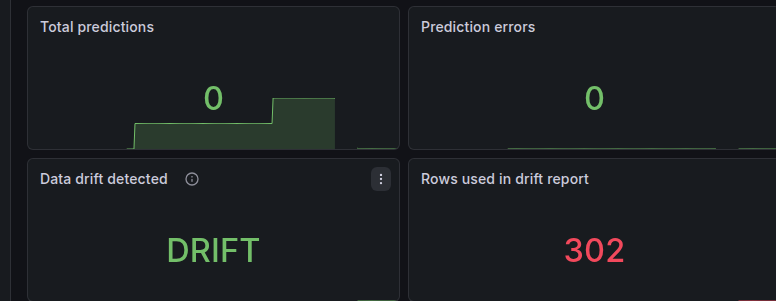

Co właśnie dodaliśmy?

### Teraz Grafana pokazuje nie tylko ruch API, ale też sygnał jakości danych:

    czy dane produkcyjne różnią się od danych treningowych

Czyli mamy już:

 - model
 - API
 - logi
 - Prometheus
 - Grafana
 - dryft

Następny krok: zrobimy automatyczne odświeżanie raportu dryftu co kilka minut przez cron albo Airflow.

przeciez samo się odświerza grafana się odświeża
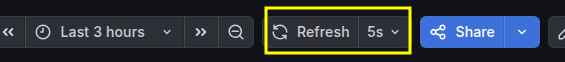

## Masz rację: Grafana sama odświeża ekran.

Ale ważne rozróżnienie:

    Grafana odświeża WIDOK.
    Nie odświeża OBLICZEŃ dryftu.

Czyli teraz działa to tak:

1. Grafana co 5 sekund pyta Prometheusa:
    „jaka jest wartość flat_price_data_drift_detected?”

2. Prometheus odpowiada wartością, którą dostał z FastAPI.

Ale sam raport:

    outputs/drift_report.json

powstaje dopiero wtedy, gdy ręcznie uruchomisz:

    python src/monitoring/drift_report.py

Czyli Grafana może się odświeżać co 5 sekund, ale jeżeli plik drift_report.json nie został przeliczony, to pokazuje stary wynik dryftu.

    Najprościej:

    Grafana = ekran
    Prometheus = pamięć metryk
    drift_report.py = liczenie dryftu

Ekran się odświeża, ale kalkulator dryftu sam się jeszcze nie uruchamia.

Dlatego potrzebujemy cron albo Airflow.

Na tym etapie nie Airflow. Jeszcze za wcześnie.

Robimy prościej:

# cron



Cron będzie co kilka minut uruchamiał: python src/monitoring/drift_report.py

Wtedy system będzie działał tak:

    nowe predykcje → logi
    cron → przelicza dryft
    FastAPI → wystawia wynik dryftu
    Prometheus → zbiera wynik
    Grafana → pokazuje wynik

# CRON

Robimy cron. Cel: co 5 minut automatycznie uruchamia się:
python src/monitoring/drift_report.py

## Krok 1. W katalogu projektu utwórz katalogi

Będąc tutaj: /root/MLOps/Projekt_1

    mkdir -p scripts
    mkdir -p logs

## Krok 2. Sprawdź ścieżkę do Pythona

    which python

/root/miniconda3/bin/python

## Krok 3. Utwórz skrypt uruchamiający dryft

    nano scripts/run_drift_report.sh

#!/bin/bash

cd /root/MLOps/Projekt_1

/root/miniconda3/bin/python src/monitoring/drift_report.py >> logs/drift_cron.log 2>&1

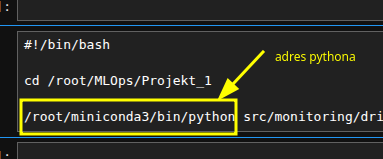

## Krok 4. Potem nadaj uprawnienia:

    chmod +x scripts/run_drift_report.sh

## Krok 5. Przetestuj ręcznie:

    ./scripts/run_drift_report.sh

To, że terminal nic nie pokazał po uruchomieniu ./scripts/run_drift_report.sh, jest normalne.

Dostałeś pustą odpowiedź w terminalu, bo w skrypcie mamy przekierowanie wyniku do pliku logu:

    >> logs/drift_cron.log 2>&1

Czyli raport nie pokazuje się na ekranie, tylko zapisuje się tutaj: logs/drift_cron.log

Teraz sprawdź:

    tail -30 logs/drift_cron.log

Jeżeli chcesz zobaczyć cały log:

    cat logs/drift_cron.log

Sprawdź też, czy raport został odświeżony:

    ls -lh outputs/drift_report.json

i podejrzyj go:

    cat outputs/drift_report.json

Jeżeli tail -30 logs/drift_cron.log pokazuje JSON z dryftem, to znaczy: skrypt działa poprawnie.
To, że terminal nic nie pokazał po uruchomieniu ./scripts/run_drift_report.sh, jest normalne.

Świetnie. Następny krok jest bardzo ważny produkcyjnie:

## Robimy z FastAPI usługę systemową

    Teraz FastAPI działa tylko wtedy, kiedy masz otwarty terminal z:

        uvicorn app.main:app --host 127.0.0.1 --port 8000

To nie jest jeszcze produkcyjne.

Chcemy, żeby API:

1. działało w tle
2. uruchamiało się samo po restarcie VPS
3. wznawiało się po awarii 
4. nie zależało od otwartego terminala

Do tego użyjemy systemd.

## Krok 1. Zatrzymaj ręczne FastAPI

W terminalu z uvicorn: CTRL + C

## Krok 2. Utwórz usługę systemową
    nano /etc/systemd/system/flat-price-api.service

[Unit]
Description=Flat Price FastAPI Model Service
After=network.target

[Service]
User=root
WorkingDirectory=/root/MLOps/Projekt_1
ExecStart=/root/miniconda3/bin/python -m uvicorn app.main:app --host 127.0.0.1 --port 8000
Restart=always
RestartSec=5
Environment=PYTHONUNBUFFERED=1

[Install]
WantedBy=multi-user.target

## Krok 3. Przeładuj systemd
    systemctl daemon-reload

## Krok 4. Włącz usługę przy starcie serwera
Tą co przefd chwilą zrobiliśmy w nano

    systemctl enable flat-price-api


## Krok 5. Uruchom usługę
    systemctl start flat-price-api

## Krok 6. Sprawdź status
    systemctl status flat-price-api


Powinno być: active (running)

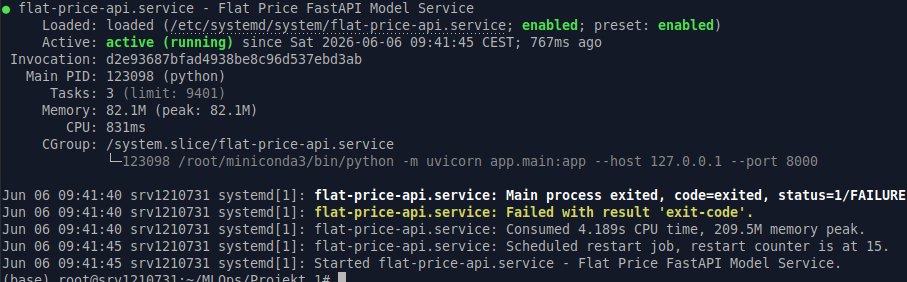

## Krok 7. Sprawdź API

    curl http://127.0.0.1:8000/health

Potem:

    curl http://127.0.0.1:8000/metrics | grep flat_price

## Krok 8. Jak oglądać logi usługi?

    journalctl -u flat-price-api -f

Wyjście:

CTRL + C

Co właśnie robimy?

 - Przechodzimy z trybu: uruchamiam API ręcznie w terminalu

 - do trybu: API działa jako prawdziwa usługa na VPS

To jest bardzo ważne w MLOps, bo model zaczyna działać jak element produkcyjnego systemu.

Po tym kroku mamy:

1. MLflow
2. FastAPI
3. logi predykcji
4. Prometheus
5. Grafana
6. drift report
7. cron
8. systemd service

Następny krok po tym: zrobimy to samo porządkowo dla Prometheusa i Grafany przez docker compose, żeby cały monitoring startował jednym poleceniem.

# Teraz robimy FastAPI jako usługę systemową, żeby działało cały czas w tle, nawet po zamknięciu terminala.

## Krok 1 — zatrzymaj ręczne FastAPI

W terminalu, gdzie działa uvicorn, naciśnij:

CTRL + C

## Krok 2 — utwórz usługę systemd

Wpisz:

    nano /etc/systemd/system/flat-price-api.service

[Unit]
Description=Flat Price FastAPI Model Service
After=network.target

[Service]
User=root
WorkingDirectory=/root/MLOps/Projekt_1
ExecStart=/root/miniconda3/bin/python -m uvicorn app.main:app --host 127.0.0.1 --port 8000
Restart=always
RestartSec=5
Environment=PYTHONUNBUFFERED=1

[Install]
WantedBy=multi-user.target

## Krok 3 — przeładuj systemd
    systemctl daemon-reload
## Krok 4 — włącz usługę przy starcie VPS
    systemctl enable flat-price-api
## Krok 5 — uruchom usługę
    systemctl start flat-price-api
## Krok 6 — sprawdź status
    systemctl status flat-price-api

Szukaj:

active (running)

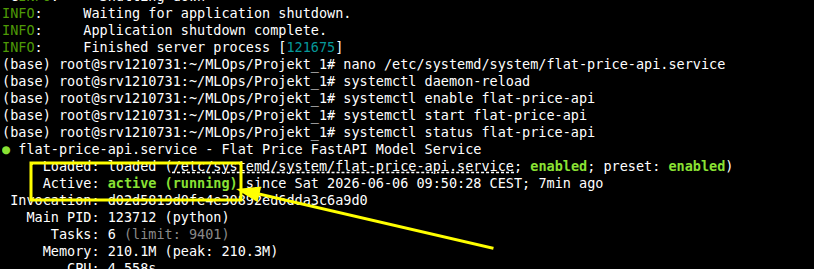

## Krok 7 — sprawdź API
    curl http://127.0.0.1:8000/health

Potem:

    curl http://127.0.0.1:8000/metrics | grep flat_price
## Krok 8 — logi usługi

Jeżeli coś nie działa:

    journalctl -u flat-price-api -n 50

Podgląd na żywo:

    journalctl -u flat-price-api -f

Wyjście:

CTRL + C

Po tym kroku model działa już jako prawdziwa usługa na VPS, a nie jako proces zależny od otwartego terminala.

## Nie, to nie koniec. To jest koniec pierwszego dużego kamienia milowego.

Teraz masz już działający system:

    model → MLflow → FastAPI → logi → Prometheus → Grafana → dryft → cron → usługa systemowa

Czyli to już nie jest tylko notebook. To jest mały produkcyjny system ML na VPS.

Ale pełna ścieżka MLOps ma jeszcze kolejne etapy.

Co mamy zrobione
1. Dane syntetyczne mieszkań
2. Trening modelu
3. Eksperymenty w MLflow
4. Wybór modelu champion
5. FastAPI do predykcji
6. Logowanie predykcji
7. Monitoring summary
8. Prometheus
9. Grafana
10. Detekcja dryftu
11. Cron do automatycznego liczenia dryftu
12. FastAPI jako usługa systemowa

To jest bardzo dużo. To już można opisać jako projekt MLOps.

## Co dalej?

Następny logiczny krok:

# ETAP 1. Porządek produkcyjny przez Docker Compose

Teraz część rzeczy działa ręcznie albo osobno:

 - FastAPI przez systemd
 - Prometheus w Dockerze
 - Grafana w Dockerze
 - cron osobno
 - MLflow osobno

Chcemy to uporządkować do jednego środowiska:

    docker-compose.yml

Czyli jednym poleceniem uruchamiasz:

    docker compose up -d

i startuje:

    FastAPI
    Prometheus
    Grafana
    MLflow

To będzie kolejny poziom produkcyjnośc

# ETAP 2. GitHub

Potem robimy repozytorium:

    flat-price-mlops-project

Dodamy:

    README.md
    requirements.txt
    .gitignore
    strukturę katalogów
    opis architektury
    instrukcję uruchomienia

I wrzucamy projekt na GitHub.

# ETAP 3. GitHub Actions

Potem dodamy CI/CD:

    push do GitHub
    → testy
    → sprawdzenie kodu
    → deployment na VPS

Czyli już nie ręcznie kopiujesz rzeczy na serwer, tylko masz automatyczny proces.

# ETAP 4. Airflow

Potem Airflow:

    trening modelu
    raport dryftu
    porównanie modeli
    retraining

Czyli pipeline ML.

# ETAP 5. Kubernetes / k3s

Na końcu przeniesiemy to z Docker Compose do lekkiego Kubernetes na VPS: 

### k3s

To będzie domknięcie największej luki z raportu.

### Najbliższy następny krok

Teraz proponuję zrobić:

    Docker Compose dla Prometheus + Grafana + FastAPI

Czyli porządkujemy uruchamianie całego systemu.

To jest naturalne przejście z:

mam działające elementy

do:

mam powtarzalne środowisko produkcyjne

# START ----> ETAP 1. Porządek produkcyjny przez Docker Compose


Cel: zamiast osobno uruchamiać FastAPI, Prometheus i Grafanę, będziesz miał jedno polecenie:

docker compose up -d --build

i startuje cały system.

## Krok 1. Zatrzymaj stare uruchomienia

W katalogu projektu:

    cd /root/MLOps/Projekt_1

Zatrzymaj FastAPI z systemd:

    systemctl stop flat-price-api
    systemctl disable flat-price-api

Usuń stare kontenery:

    docker rm -f prometheus grafana

## Krok 2. Sprawdź Docker Compose
    docker compose version

Jeżeli pokaże wersję, jest dobrze.

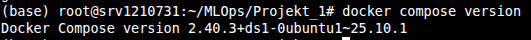

## Krok 3. Utwórz requirements.txt

Żeby Docker miał te same biblioteki:

    nano requirements.txt

Wklej:

    fastapi
    uvicorn[standard]
    pydantic
    pandas
    numpy
    scikit-learn
    mlflow
    prometheus-client
    matplotlib
    requests

Zapisz:

    CTRL + O
    ENTER
    CTRL + X

## Krok 4. Utwórz Dockerfile
    nano Dockerfile

Wklej cały plik:

FROM python:3.13-slim

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

WORKDIR /root/MLOps/Projekt_1

RUN apt-get update && apt-get install -y --no-install-recommends \
    build-essential \
    curl \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

CMD ["python", "-m", "uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"]

## Krok 5. Popraw konfigurację Prometheusa

W Docker Compose Prometheus nie będzie czytał:

    127.0.0.1:8000

tylko nazwę kontenera:

    flat-price-api:8000

Otwórz plik:

    nano monitoring/prometheus/prometheus.yml

Wklej całość:

    global:
      scrape_interval: 5s

    scrape_configs:
      - job_name: "flat_price_api"
        metrics_path: "/metrics"
        static_configs:
          - targets: ["flat-price-api:8000"]

Zapisz.

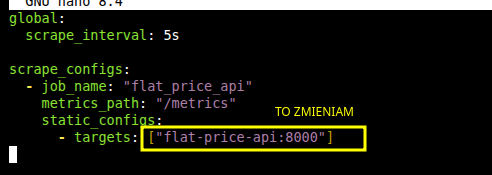

## Krok 6. Dodaj automatyczne źródło danych Grafany

    mkdir -p monitoring/grafana/provisioning/datasources
    nano monitoring/grafana/provisioning/datasources/prometheus.yml

## Krok 7. Utwórz docker-compose.yml
    nano docker-compose.yml

## Krok 8. Uruchom cały system
    docker compose up -d --build

To może chwilę potrwać, bo Docker zbuduje obraz FastAPI.

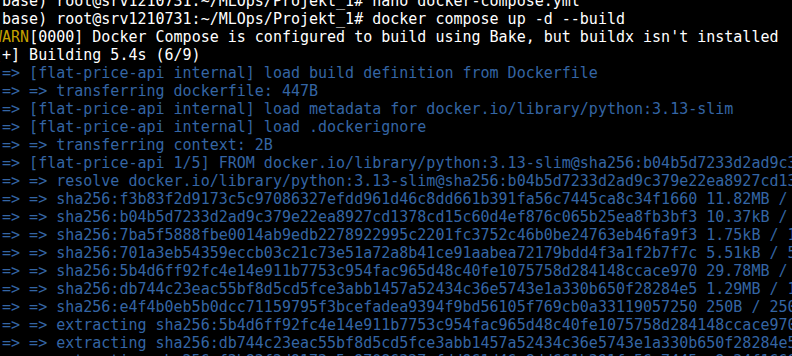

TAK KOŃCZY:


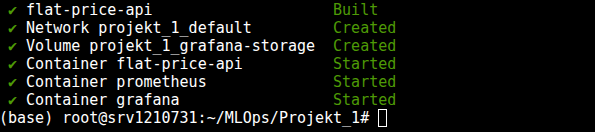

## Krok 9. Sprawdź kontenery
    docker compose ps

Powinieneś zobaczyć:

    flat-price-api
    prometheus
    grafana

ze statusem running.

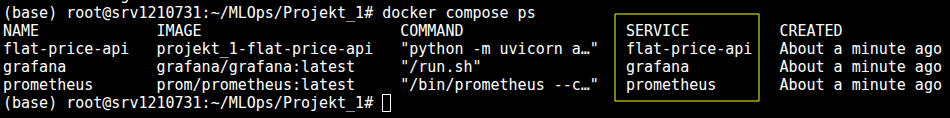

## Krok 10. Sprawdź API
    curl http://127.0.0.1:8000/health

Sprawdź metryki:

    curl http://127.0.0.1:8000/metrics | grep flat_price

Sprawdź Prometheusa:

    curl http://127.0.0.1:9090/-/healthy

Sprawdź Grafanę:

    curl http://127.0.0.1:3000/api/health

## Krok 11. Wgraj dashboard do Grafany


#### Co teraz osiągamy

Przechodzisz z ręcznego uruchamiania:

    systemd + osobne docker run + ręczne komendy

do powtarzalnego środowiska:

    docker-compose.yml

Czyli teraz system startuje jednym poleceniem:

#    docker compose up -d --build

a zatrzymuje się jednym poleceniem:

#    docker compose down

To jest kolejny realny krok MLOps: powtarzalne środowisko produkcyjne na VPS.

# START ----> ETAP 2. GitHub

GitHub jest po to, żeby projekt przestał być „folderem na VPS”, a stał się kontrolowanym projektem inżynierskim.

Najprościej:

    VPS = miejsce, gdzie system działa
    GitHub = miejsce, gdzie system jest opisany, zapisany i kontrolowany
    Po co nam GitHub w tym projekcie?

## Po pierwsze: historia zmian.

Jeżeli zmienisz app/main.py i coś zepsujesz, GitHub pozwala wrócić do wcześniejszej wersji.

## Po drugie: porządek projektu.

Na GitHubie pokazujesz:

    kod modelu
    FastAPI
    Docker Compose
    Prometheus
    Grafanę
    skrypty dryftu
    README
    strukturę projektu

Czyli ktoś widzi, że to nie jest chaos, tylko projekt MLOps.

## Po trzecie: CV i rekrutacja.

Możesz powiedzieć:

Mam repozytorium z pełnym projektem ML: trening, MLflow, API, Docker Compose, monitoring, drift detection i dashboard Grafana.

To brzmi dużo lepiej niż:

Mam notebook z modelem.

## Po czwarte: GitHub Actions, czyli następny etap.

GitHub może automatycznie robić:

    sprawdzenie kodu
    uruchomienie testów
    budowanie aplikacji
    deployment na VPS

Czyli GitHub staje się początkiem CI/CD.

Bardzo prosta analogia

VPS to restauracja, gdzie działa kuchnia.
GitHub to książka receptur, historia zmian, kontrola jakości i instrukcja dla całego zespołu.
Bez GitHuba system działa, ale trudno go kontrolować.
Z GitHubem system zaczyna wyglądać profesjonalnie.

Co teraz zrobimy?
Teraz wrzucimy projekt do repozytorium:

    flat-price-mlops-project

Dodamy:

    .gitignore
    README.md
    requirements.txt
    docker-compose.yml
    strukturę katalogów
    pierwszy commit

To będzie przejście z „działa na moim VPS” do „mam projekt, który można pokazać i odtworzyć”.

chat GPT:  https://chatgpt.com/g/g-p-6a225d72bfd0819195fb28948eae59fc/c/6a2149df-d2f0-8393-bbfa-209ab56eea12

# START ----> ETAP 2. GitHub

Robimy Git. Cel: kod i konfiguracja idą na GitHub, ale bazy, logi i artefakty modeli nie idą.

## Krok 1. Sprawdź, czy masz Git
    git --version

jeżeli nie ma:

    apt update
    apt install -y git

Co to znaczy że git jest na środowisku? Myslałem że to magazyn na chmurze

Git to nie jest chmura. Git to program/narzędzie zainstalowane w Twoim środowisku, czyli np. na VPS, Ubuntu, serwerze albo laptopie. A GitHub to magazyn w chmurze, gdzie wysyłasz kod.

    Czyli masz dwa elementy:

1. Git lokalnie / w środowisku. To jest narzędzie, które działa u Ciebie w katalogu:

/root/MLOps/Projekt_1

Git pilnuje historii zmian:

    git status
    git add .
    git commit -m "first commit"

Czyli Git mówi: zapamiętuję stan projektu, wiem co się zmieniło, mogę wrócić do poprzedniej wersji.

2. GitHub w chmurze. To jest zdalny magazyn kodu. Tam wysyłasz projekt komendą:

    git push

Czyli GitHub mówi: przechowuję Twoje repozytorium online, możesz je pokazać rekruterowi, podłączyć CI/CD, GitHub Actions itd.

Najprościej

    Git = lokalny system kontroli wersji
    GitHub = chmurowe miejsce na repozytoria Git

Tak jak:

    Word na komputerze ≠ Google Drive
    Git na serwerze ≠ GitHub w chmurze

Git musi być zainstalowany w Twoim środowisku, żebyś mógł z tego środowiska wysłać kod na GitHub.

Dlatego sprawdzamy:

git --version

To znaczy:

Czy ten serwer/VPS ma zainstalowane narzędzie Git, którym będziemy zarządzać kodem i wysyłać go do GitHuba.

## Krok 2. Ustaw swoje dane Git
    git config --global user.name "Wojciech Moszczynski"
    git config --global user.email "wtm695450085@gmail.com"

## Krok 3. Utwórz .gitignore
    nano .gitignore

## Krok 4. Sprawdź, co Git będzie 
    git status






Jeżeli Git jeszcze nie działa w tym katalogu, zrób:

    git init


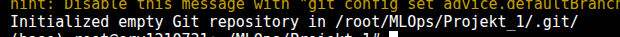



Potem znowu:

    git status

## Krok 5. Utwórz prosty README
    nano README.md

## Krok 6. Run with Docker Compose
czyli pobudzam server ten co go budowałem

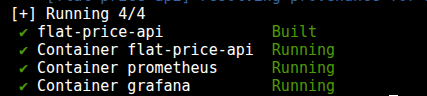


    docker compose up -d --build

## Krok 6. Zrób pierwszy commit
    
    git commit -m "Initial MLOps project structure"

-----------------------------------------------------

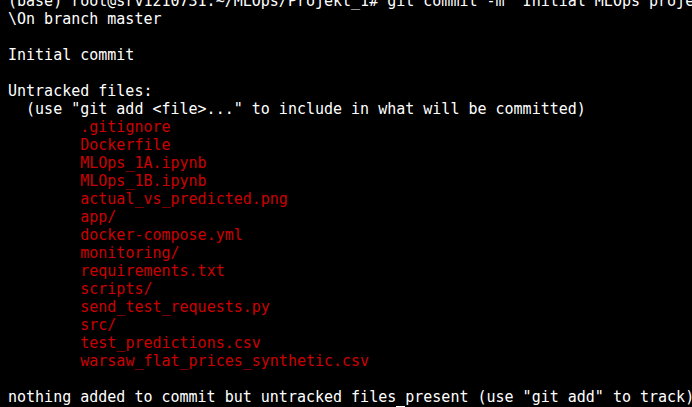

Zrób pierwszy commit znaczy:

<div class="alert-info"; span style="font-size: 160% "> zapisz aktualny stan projektu w historii Gita jako pierwszy punkt kontrolny.

Czyli Git robi coś jak zdjęcie projektu w tym momencie.</div>

Rozbijmy to
git commit

oznacza:

#### utwórz zapis zmian w historii projektu.

To nie wysyła jeszcze nic na GitHub.
To zapisuje zmiany lokalnie, na Twoim VPS / środowisku.

    -m

oznacza: message, czyli wiadomość/opis commita: "Initial MLOps project structure"

to opis tego zapisu.

Po polsku: Początkowa struktura projektu MLOps

Czyli mówisz Gitowi: zapamiętaj ten stan projektu jako pierwszy porządny zapis: katalogi, pliki, konfigurację Docker, FastAPI, Prometheus, Grafana itd.

### Ważne

Przed commit zwykle robi się:

    git add .

font-weight: lighter; color: #1155cc; font-family: 'Trebuchet MS';

To znaczy: dodaj pliki do paczki, którą chcę zapisać.

Potem:

    git commit -m "Initial MLOps project structure"

To znaczy: zapisz tę paczkę w historii projektu.

Prosta analogia

Masz projekt jako zeszyt.

    git add .

oznacza: zaznaczam strony, które chcę zapisać.

    git commit -m "Initial MLOps project structure"

oznacza: robię trwały zapis: „wersja numer 1 projektu”.

### Najważniejsze - Commit to lokalny zapis wersji projektu.

GitHub pojawia się dopiero przy:

    git push

Czyli kolejność jest taka:

    git add .
    git commit -m "Initial MLOps project structure"
    git push

W skrócie:

    add = wybieram pliki
    commit = zapisuję wersję lokalnie
    push = wysyłam na GitHub

## INFORMACJA_1. API endpoints

GET  /health
POST /predict
GET  /metrics
GET  /monitoring/summary
GET  /monitoring/drift
GET  /logs/recent

<div class="alert-info"; span style="font-size: 160% "> To jest lista endpointów API, czyli adresów, pod które można wejść w Twojej aplikacji FastAPI.</div>

Najprościej:

    API endpoint = konkretne drzwi do jednej funkcji aplikacji.

Masz takie drzwi:

### GET /health

Sprawdza, czy aplikacja żyje.

Przykład:

    curl http://localhost:8000/health

Powinno zwrócić coś typu:

    {"status": "ok"}

### POST /predict

Tu wysyłasz dane mieszkania, a model zwraca predykcję ceny.

Przykład:
„mam mieszkanie 50 m², 5 km od centrum, piętro 2” → model wylicza cenę.

To jest główny endpoint biznesowy.

### GET /metrics

To czyta Prometheus.

Tam są metryki techniczne, np.:

    request_count
    request_latency
    prediction_count

Czyli: ile było zapytań, jak szybko działa API, czy są błędy.

### GET /monitoring/summary

To daje krótkie podsumowanie monitoringu.

Na przykład:

    {
      "total_predictions": 120,
      "avg_prediction": 745000,
      "errors": 0
    }

Czyli szybka informacja: co się dzieje z aplikacją.

### GET /monitoring/drift

To pokazuje informację o dryfcie danych.

Czyli odpowiada na pytanie: Czy dane, które teraz przychodzą do modelu, są podobne do danych treningowych?

Przykład:

    {
      "drift_detected": true,
      "changed_features": ["area", "rent"]
    }

To jest bardzo ważne w MLOps, bo model może działać gorzej, gdy dane zaczynają się zmieniać.

### GET /logs/recent

Pokazuje ostatnie logi aplikacji.

Czyli np.:

    2026-06-07 12:01 prediction made
    2026-06-07 12:03 drift report generated

To pomaga sprawdzić, co aplikacja robiła ostatnio.

W skrócie:

    Endpoint	Co robi
    /health	sprawdza, czy API działa
    /predict	robi predykcję modelem
    /metrics	daje metryki dla Prometheusa
    /monitoring/summary	pokazuje podsumowanie działania
    /monitoring/drift	pokazuje dryft danych
    /logs/recent	pokazuje ostatnie logi

Czyli ten fragment mówi:

Twoja aplikacja ma już nie tylko model, ale też monitoring, metryki, dryft i logi. To zaczyna wyglądać jak prawdziwy projekt MLOps.

## INFORMACJA_2. Example prediction 

## INFORMACJA_2. Monitoring

Prometheus collects metrics from:

    http://flat-price-api:8000/metrics

Grafana is available locally on:

    http://127.0.0.1:3000

## DIAGNOSTYKA_3. Czy działa system 

    cd /root/MLOps/Projekt_1
    docker compose ps



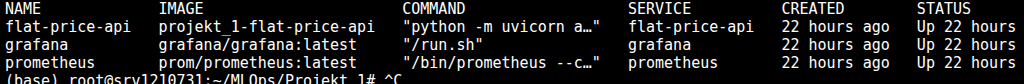

Czyli Docker żyje. Teraz problem prawdopodobnie jest w tym, że port 8000 nie jest wystawiony na zewnątrz albo FastAPI słucha tylko lokalnie.

## DIAGNOSTYKA_4. Pokaż porty kontenerów

    docker compose ps --format "table {{.Name}}\t{{.Service}}\t{{.Status}}\t{{.Ports}}"


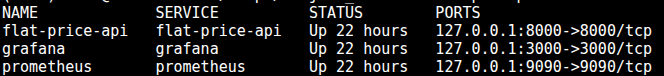

## DIAGNOSTYKA_5. Sprawdź, czy API działa wewnątrz VPS

    curl http://127.0.0.1:8000/health



    curl http://127.0.0.1:8000/metrics

## DIAGNOSTYKA_6. RESETOWANIE SYSTEMU

    docker compose down
    docker compose up -d --build

-----------------------------------------------------------------------
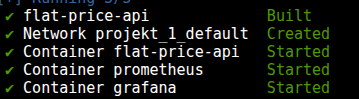

DIAGNOSTYKA_6. Sprawdź porty
    
    docker compose ps --format "table {{.Name}}\t{{.Service}}\t{{.Status}}\t{{.Ports}}"


---------------------------------------------
Są 3 porty pokazane:

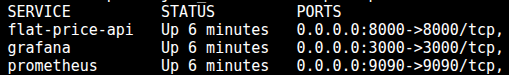


## DIAGNOSTYKA_7. PROMETHEUS 
- NA POCZATKU TRZEBA WPISAC ADRES MOJEGO SERWERA VPS

  Tam będzie pole do wpisywania zapytania, zwykle na górze.

W to pole wpisz:

flat_price_predictions_total

Prometheus znalazł metrykę:

flat_price_predictions_total

I pokazuje, że zbiera ją z Twojego API:

instance="flat-price-api:8000"
job="flat_price_api"

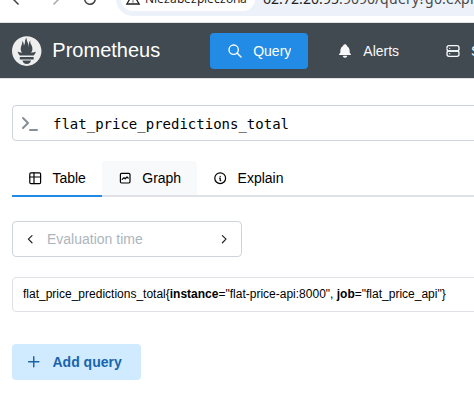
